# **Exploratory Data Analysis: After Pupil Detection**

**Authors:** Katrine Bjerre (katbj@itu.dk) & Kristine Emilie Risager Pedersen (krep@itu.dk)

Last edited: 17.03.2026

## **Table of Contents**

1. [Imports](#imports)
2. [Dataset Indexing](#dataset-indexing)
3. [General Information](#general-information)
    - [Dataset overview](#dataset-overview)
    - [Unique values](#unique-values)
    - [Missing values](#missing-values)
    - [Target balance](#target-balance)
    - [Image resolution](#image-resolution)
    - [Image color mode](#image-color-mode)
4. [Distributions](#distributions)
    - [Image distribution per subject](#image-distribution-per-subject)
    - [Image distribution per target](#image-distribution-per-target)
    - [Subject-Target distribution](#subject-target-distribution)
5. [Sample Images](#sample-images)
    - [Cleaned samples](#cleaned-samples)
    - [Samples with failed pupil detection](#samples-where-pupil-detection-failed)

<br/>

## **Imports**

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

<br/>

## **Dataset Indexing**

In [2]:
# Project paths
ROOT_DIR = Path("../..").resolve()
DATA_DIR = ROOT_DIR / "data"

# Create DataFrame
df = pd.read_csv(ROOT_DIR / "data_utils" / "metadata.csv")

print("Rows after pupil detection:", len(df))
df.head()

Rows after pupil detection: 108136


,subject,target,x_norm,y_norm,x_pixel,y_pixel,path
0,1,0,0.15,0.15,216.0,135.0,data/001/frames/00_1771844694463536000.png
1,1,0,0.15,0.15,216.0,135.0,data/001/frames/00_1771844694495373000.png
2,1,0,0.15,0.15,216.0,135.0,data/001/frames/00_1771844694526693000.png
3,1,0,0.15,0.15,216.0,135.0,data/001/frames/00_1771844694557769000.png
4,1,0,0.15,0.15,216.0,135.0,data/001/frames/00_1771844694589347000.png


In [3]:
df.sample(30)

,subject,target,x_norm,y_norm,x_pixel,y_pixel,path
52282,23,10,0.150,0.500,216.0,450.0,data/023/frames/10_1771952765726166000.png
65370,28,22,0.500,0.850,720.0,765.0,data/028/frames/22_1772036938816500000.png
76947,33,18,0.675,0.675,972.0,607.5,data/033/frames/18_1772102681177842000.png
6500,4,2,0.500,0.150,720.0,135.0,data/004/frames/02_1771847302618111000.png
43484,19,17,0.500,0.675,720.0,607.5,data/019/frames/17_1771949257177786000.png
30905,14,7,0.500,0.325,720.0,292.5,data/014/frames/07_1771934788130929000.png
86059,37,15,0.150,0.675,216.0,607.5,data/037/frames/15_1772194500148465000.png
105351,45,20,0.150,0.850,216.0,765.0,data/045/frames/20_1772206641652749000.png
46313,20,23,0.675,0.850,972.0,765.0,data/020/frames/23_1771950515118592000.png
79231,34,17,0.500,0.675,720.0,607.5,data/034/frames/17_1772109540616653000.png


<br/>

## **General Information**

### Dataset Overview

In [4]:
print("Total images:", len(df))
print("Unique subjects:", df.subject.nunique())
print("Unique targets:", df.target.nunique())

Total images: 108136
Unique subjects: 46
Unique targets: 25


### Unique values

In [5]:
print("Unique subjects:", df["subject"].nunique())
print("Unique targets:", df["target"].nunique())
print("\nUnique x_norm:", sorted(df["x_norm"].unique()))
print("Unique y_norm:", sorted(df["y_norm"].unique()))

Unique subjects: 46
Unique targets: 25

Unique x_norm: [np.float64(0.15), np.float64(0.325), np.float64(0.5), np.float64(0.675), np.float64(0.85)]
Unique y_norm: [np.float64(0.15), np.float64(0.325), np.float64(0.5), np.float64(0.675), np.float64(0.85)]


### Missing values

In [6]:
print(df.isnull().sum())

subject    0
target     0
x_norm     0
y_norm     0
x_pixel    0
y_pixel    0
path       0
dtype: int64


### Target balance

In [7]:
target_counts = df["target"].value_counts().sort_index()
#print(target_counts)

target_counts.describe()

count      25.000000
mean     4325.440000
std        26.407196
min      4252.000000
25%      4308.000000
50%      4325.000000
75%      4345.000000
max      4367.000000
Name: count, dtype: float64

### Image Resolution

In [8]:
sizes = []

sample_paths = df.path.sample(2000, random_state=42)

for p in tqdm(sample_paths):
    with Image.open(ROOT_DIR / p) as img:
        sizes.append(img.size)

pd.Series(sizes).value_counts()

100%|██████████| 2000/2000 [00:24<00:00, 82.35it/s]


(2048, 1536)    2000
Name: count, dtype: int64

### Image Color Mode

In [9]:
modes = []

for p in tqdm(sample_paths):
    with Image.open(ROOT_DIR / p) as img:
        modes.append(img.mode)

pd.Series(modes).value_counts()

100%|██████████| 2000/2000 [00:23<00:00, 83.53it/s]


RGB    2000
Name: count, dtype: int64

<br/>

## **Distributions**

### Image Distribution per Subject

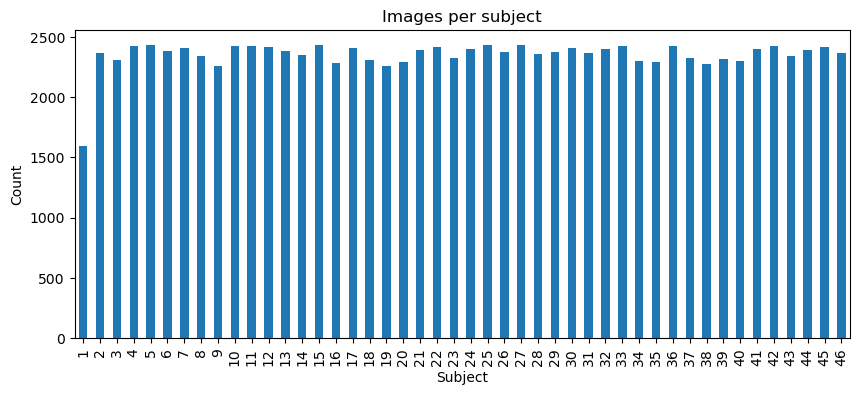

In [10]:
subject_counts = df.subject.value_counts().sort_index()
#print(subject_counts)

plt.figure(figsize=(10,4))
subject_counts.plot(kind="bar")
plt.title("Images per subject")
plt.xlabel("Subject")
plt.ylabel("Count")
plt.show()

### Image Distribution per Target

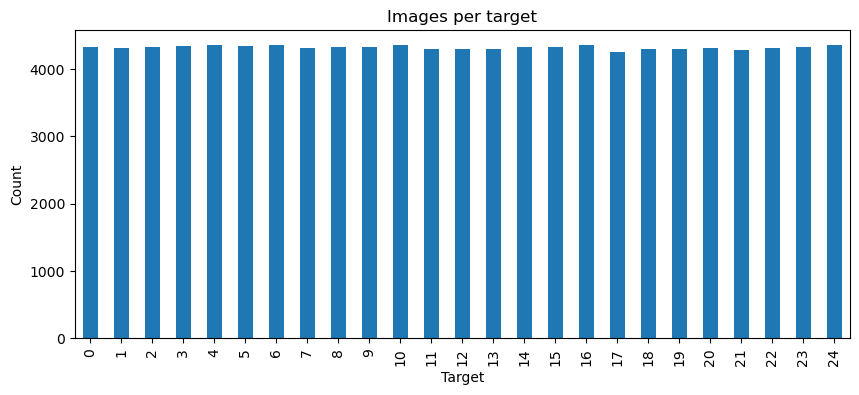

In [11]:
target_counts = df.target.value_counts().sort_index()
#print(target_counts)

plt.figure(figsize=(10,4))
target_counts.plot(kind="bar")
plt.title("Images per target")
plt.xlabel("Target")
plt.ylabel("Count")
plt.show()

### Subject-Target Distribution

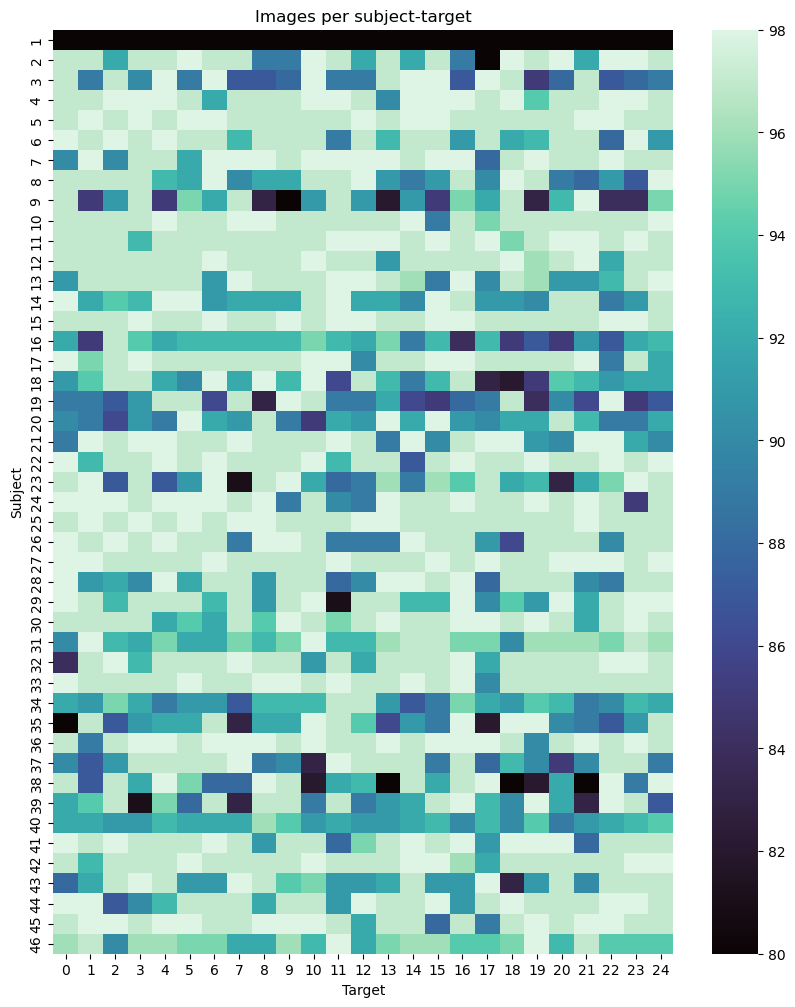

In [12]:
pivot = pd.crosstab(df.subject, df.target)
#print(pivot)

plt.figure(figsize=(10,12))
sns.heatmap(pivot, cmap="mako", vmin=80, vmax=98)
plt.title("Images per subject-target")
plt.xlabel("Target")
plt.ylabel("Subject")
plt.show()

<br/>

## **Sample images**

### Cleaned samples

In [ ]:
sample = df.sample(25, random_state=42)

plt.figure(figsize=(10, 10))

for i, row in enumerate(sample.itertuples()):
    with Image.open(ROOT_DIR / row.path) as img:
        plt.subplot(5, 5, i + 1)
        plt.imshow(img)
        plt.title(f"S:{row.subject} T:{row.target}")
        plt.axis("off")

plt.tight_layout()
plt.show()

### Samples with failed pupil detection

In [ ]:
df_failed_pupil_detection = pd.read_csv(
    ROOT_DIR / "preprocessing" / "pupil_detection" / "failed_pupil_detection.csv"
)

df_failed_pupil_detection["image_path"] = (
    df_failed_pupil_detection["image_path"]
    .str.replace("../", "", regex=False)
    .str.strip()
)

sample = df_failed_pupil_detection.sample(25, random_state=42)

plt.figure(figsize=(10, 10))

for i, row in enumerate(sample.itertuples()):
    with Image.open(ROOT_DIR / row.image_path) as img:
        plt.subplot(5, 5, i + 1)
        plt.imshow(img)
        plt.axis("off")

plt.tight_layout()
plt.show()